# `skmb` — strat-column → GeoModel (interface + unit hybrid, baselap-onto-conformal)

The Saskatchewan/Manitoba basin column (45 units, conformal/baselap/eroded) observed as
**both** on-contact **interface** points (`markers.vtp`) **and** interior **unit** points
(`units.vtp`). This is the example that combines the two constraint families and adds the
**baselap-onto-conformal** relationship:

* **interfaces → surfaces.** Every contact (and every unconformity) gets an `eq` trace +
  a **seed isosurface** from its interface points, so its iso-value is pinned by the data —
  no learnable iso-values (contrast wcsb, where the isos are learned).
* **units → labels.** The interior unit points drive the **soft-unit / NLL coupling**
  (`attach_unit_loss(seed_isos=True)`): each epoch the field stack + the *seeded* contacts
  are carved into an `(N, C)` per-class simplex and trained with cross-entropy against the
  true unit levels.
* **baselap-onto-conformal.** Four baselap units (Westgate, Torquay, 1stRedBed,
  Winnipegosis) lap onto the **top of the conformal package below** them rather than an
  unconformity. `build_geomodel` splits the package at the baselap and onlaps the upper
  package onto the lower package's **top isosurface** (the youngest interface of the lower
  package).

Pipeline: **load → partition (baselap splits) → structure → joint fit → per-field fields →
combined predict / 3D → checks**.

## 0. Setup

In [1]:
%matplotlib inline
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import curlew
from curlew.io import loadObservations
from curlew.geology.stratbuilder import build_geomodel, attach_unit_loss
from curlew.geology.softunit import soft_unit_probs

DEVICE = os.environ.get("CURLEW_DEVICE", "cuda")
if DEVICE.startswith("cuda") and not torch.cuda.is_available():
    raise RuntimeError("CUDA requested but unavailable; set CURLEW_DEVICE=cpu to run on CPU.")
curlew.device = DEVICE
torch.manual_seed(0); np.random.seed(0)

CANDIDATES = [
    r"D:/Development/GeoINR_Research2/geoinr/data/skmb",
    os.path.join(os.path.dirname(os.getcwd()), "data", "skmb"),
    "./data/skmb",
]
DATA = next((p for p in CANDIDATES if os.path.exists(os.path.join(p, "strat_column.csv"))), None)
assert DATA is not None, f"Could not locate skmb data; tried {CANDIDATES}"
STRAT_CSV = os.path.join(DATA, "strat_column.csv")

# --- build knobs (reproducible) ---------------------------------------------
FIELD = "Siren"
if FIELD == "Siren":
    FIELD_KWARGS = dict(omega0=30.0, omega=30.0, learning_rate=1e-4, hidden_dim=256)
else:  # softplus MLP
    FIELD_KWARGS = dict(activation=nn.Softplus(beta=40), learning_rate=1e-3, hidden_dim=256)
CAP_PER_UNIT = 20000   # balance comes from POINTS_PER_LEVEL on the coupled path; keep generous
IQ_SAMPLES   = 256    # iq samples/pair per epoch (4x cheaper than 1024; accuracy-neutral)
REG_SAMPLES  = 2000   # model-scaled Poisson no-overturn samples; even basin-margin coverage (->5000 = marginally cleaner margins at ~40% more runtime)
N_EPOCHS     = 2000   # robust to over-training at overturn=12 (volume gets cleaner with epochs); raise freely

# --- soft-unit / NLL coupling knobs -----------------------------------------
# seed_isos=True: contacts are pinned by the interface data (eq + seed isosurfaces); the
# coupling owns NO learnable iso-values. The fields keep their interface (eq_norm) loss so the
# contacts stay on the data, and the gradient-normalised inequalities (iq_norm) stay ON to
# ORDER the surfaces where the CE is silent: within a package (younger contact above older) and
# across unconformities (older surfaces stay below a younger iso, one pair per older surface) —
# the deep, unit-sparse regions where a younger unconformity would otherwise erode below an
# older one (e.g. the Precambrian). The hinge is zero once satisfied, so it only corrects
# violations. overturn is relaxed (CE orders the units at the markers).
TAU              = 0.05
POINTS_PER_LEVEL = 1024
# no-overturn weight (applied to every coupled field). The CE pins ordering at the data, so a
# light prior suffices near the markers; but the deep, *unconstrained* regions between markers
# can still overturn — which shows up as occasional isolated younger-unit islands inside older
# rock. Raise this (e.g. 12-30) for a cleaner volume (fewer such islands) at some cost to
# marker fit; lower it for a tighter fit with more deep-region inversions. Default 6 (the
# wcsb-tuned coupled value).
OVERTURN_WEIGHT  = 12.0  # seed-iso path: stiffer than wcsb-coupled 6 (interface eq adds deep-region curvature) -> robust to over-training
print("device:", curlew.device, "| field:", FIELD, "| data:", DATA)

device: cuda | field: Siren | data: D:/Development/GeoINR_Research2/geoinr/data/skmb


## 1. Load & normalize

Read the strat column and **both** observation files: `markers.vtp` (interface / on-contact
points) and `units.vtp` (interior unit points). Because interface points are present *and*
the column has unconformities + baselap-onto-conformal splits, `build_geomodel` uses the
**chain path** and **seeds** every surface from the interface points. An anisotropic
(`geo_extensive`) normalization handles the basin's wide-and-thin geometry.

In [2]:
obs = loadObservations(interfaces=os.path.join(DATA, "markers.vtp"),
                       units=os.path.join(DATA, "units.vtp"))
print("observations:", f"{int(obs.is_interface.sum()):,} interface +",
      f"{int((~obs.is_interface).sum()):,} unit points |", obs.ndim, "D |",
      f"{len(obs.levels('unit'))} unit levels")

M = build_geomodel(STRAT_CSV, obs, field=FIELD, scale="geo_extensive",
                   cap_per_unit=CAP_PER_UNIT, iq_samples=IQ_SAMPLES, reg_samples=REG_SAMPLES, seed=0,
                   field_kwargs=FIELD_KWARGS)
T = M.normalization

observations: 152,082 interface + 358,371 unit points | 3 D | 44 unit levels


In [3]:
try:
    import pandas as pd
    display(pd.DataFrame([{"index": i, "name": u.name, "relation": u.relation, "level": u.level}
                          for i, u in enumerate(M.strat_units)]))
except Exception:
    for i, u in enumerate(M.strat_units):
        print(i, u.name, u.relation, u.level)

,index,name,relation,level
0,0,Above_BellyRiver,conformal,2
1,1,BellyRiver,conformal,3
2,2,LeaPark_Milwood_Pembina,baselap,4
3,3,Unconformity_Sub_Lea_Park,eroded,5
4,4,UpperColorado_Carlile,conformal,6
5,5,2ndWhiteSpecks_Favel_BelleFourche,conformal,7
6,6,Fish_Scale,conformal,8
7,7,Westgate,baselap,9
8,8,Viking_Newcastle_FlottenLake,conformal,10
9,9,JoliFou_Pense_Cantuar_SkullCreek_SwanRiver,baselap,11


## 2. Scalar-field partitioning & baselap-onto-conformal (visual)

The builder emits an oldest→youngest chain: a region-only **basement**, then erosional
unconformities each followed by the depositional package that **onlaps** it. The new
behaviour for skmb is the **baselap-onto-conformal split**: a run of conformal units is
broken at each `baselap` unit, and the upper package onlaps the **top of the package below**
(not an unconformity). The four such packages — Westgate, Torquay, 1stRedBed, Winnipegosis —
are listed with the lower-package top they lap onto.

derived events (oldest -> youngest):
  region-only Precambrian                    levels=[46]       
  erosional   Precambrian Unconformity       L46 eroded        
  depositional Deadwood                       levels=[40, 41, 42, 43, 44, 45]  onlaps Precambrian Unconformity
  erosional   Unconformity_Top_LPaleo Unconf L40 eroded        
  depositional MeadowLake                     levels=[38, 39]     onlaps Unconformity_Top_LPaleo Unconf
  depositional Winnipegosis                   levels=[34, 35, 36, 37]  --baselaps onto--> MeadowLake top
  depositional 1stRedBed                      levels=[30, 31, 32, 33]  --baselaps onto--> Winnipegosis top
  depositional Torquay                        levels=[28, 29]     --baselaps onto--> 1stRedBed top
  erosional   Unconformity_Sub_Miss Unconfor L28 eroded        
  depositional Bakken                         levels=[19, 20, 21, 22, 23, 24, 25, 26, 27]  onlaps Unconformity_Sub_Miss Unconfor
  erosional   Unconformity_Sub_Mesozoic Unco L19 ero

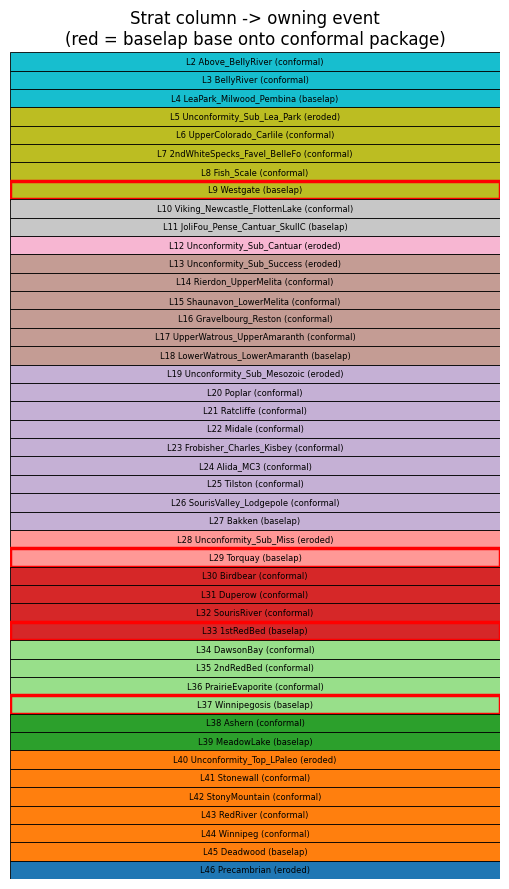

In [4]:
print("derived events (oldest -> youngest):")
for ev, meta in zip(M.events, M.field_meta):
    onl = ""
    if meta.onlap_package:
        onl = f"  --baselaps onto--> {meta.onlap_event[:30]} top"
    elif meta.onlap_event:
        onl = f"  onlaps {meta.onlap_event[:30]}"
    extra = (f"L{meta.eroded_level} eroded" if meta.is_unconformity
             else (f"levels={meta.levels}" if meta.levels else ""))
    print(f"  {meta.kind:11s} {meta.name[:30]:30s} {extra:18s}{onl}")

print("\nbaselap-onto-conformal packages (the new pattern):")
for meta in M.field_meta:
    if meta.onlap_package:
        lower = next(x for x in M.field_meta if x.name == meta.onlap_event)
        print(f"  {meta.name[:26]:26s} (base baselap) laps onto top of "
              f"{meta.onlap_event[:30]:30s} = '{lower.top_iso}'")

units = M.strat_units; n = len(units)
ev_of_level = {L: k for k, meta in enumerate(M.field_meta) for L in meta.levels}
onlap_levels = {L for meta in M.field_meta if meta.onlap_package for L in meta.levels}
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(5.2, 9))
for i, u in enumerate(units):
    y = n - 1 - i; k = ev_of_level.get(u.level, -1)
    fc = cmap(k % 20) if k >= 0 else "lightgray"
    ec = "red" if u.level in onlap_levels and u.relation == "baselap" else "k"
    lw = 2.5 if ec == "red" else 0.6
    ax.add_patch(plt.Rectangle((0, y), 1, 1, facecolor=fc, edgecolor=ec, linewidth=lw))
    ax.text(0.5, y + 0.5, f"L{u.level} {u.name[:28]} ({u.relation})", ha="center", va="center", fontsize=6)
ax.set_xlim(0, 1); ax.set_ylim(0, n); ax.axis("off")
ax.set_title("Strat column -> owning event\n(red = baselap base onto conformal package)")
plt.tight_layout(); plt.show()

**GeoModel event graph** (`_repr_svg_`):

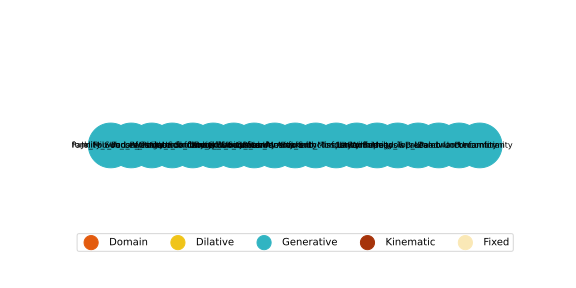

In [5]:
M

## 3. Joint fit — seed-iso soft-unit / NLL coupling

`attach_unit_loss(M, seed_isos=True)` builds a `UnitLoss` whose carve reads each contact's
iso-value from its interface-**seeded** isosurface (re-evaluated each step, grad-carrying)
rather than from learnable parameters. Each epoch it samples `POINTS_PER_LEVEL` balanced
unit points per level, carves an `(N, C)` per-class simplex (`soft_unit_probs`), and trains
the NLL against the true unit levels. The fields keep their **interface** (`eq_norm`) loss
so the contacts stay pinned to the on-contact data while the unit points calibrate the
classification. Nothing is written post-fit — the seeds resolve directly at `M.predict`.

coupling: 45 level-classes | 0 learnable iso params (0 = seeded) | 44 seeded thresholds | tau=0.05 (s=20)


Training            0/2000 

final loss: 0.7375058315777971


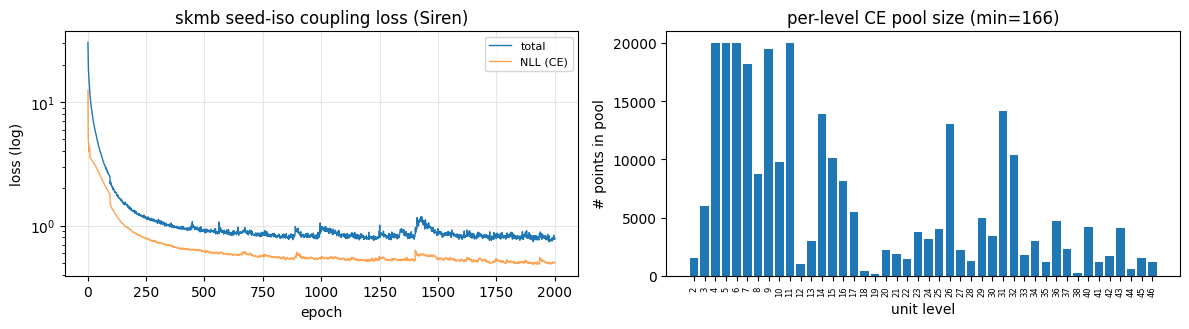

In [6]:
uloss = attach_unit_loss(M, tau=TAU, points_per_level=POINTS_PER_LEVEL,
                         overturn_weight=OVERTURN_WEIGHT, seed_isos=True)
print(f"coupling: {uloss.n_classes} level-classes | {len(list(uloss._params))} learnable iso params "
      f"(0 = seeded) | {len(uloss.spec.seed_map)} seeded thresholds | tau={uloss.tau} (s={1/uloss.tau:.0f})")

loss, pebble, history = M.fit(N_EPOCHS, early_stop=None, best=False, history=True, custom_loss=[uloss])
print("final loss:", loss)

losses = [p.total() for p in history]
nll = [p.losses.get("unit", {}).get("nll_loss", np.nan) for p in history]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(np.arange(1, len(losses) + 1), losses, lw=1, label="total")
ax[0].plot(np.arange(1, len(nll) + 1), nll, lw=1, alpha=0.7, label="NLL (CE)")
ax[0].set_yscale("log"); ax[0].legend(fontsize=8)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss (log)"); ax[0].grid(True, alpha=0.3)
ax[0].set_title(f"skmb seed-iso coupling loss ({FIELD})")
rep = {L: len(M.level_points.get(L, ())) for L in obs.levels("unit")}
levels_sorted = sorted(rep)
ax[1].bar([str(L) for L in levels_sorted], [rep[L] for L in levels_sorted])
ax[1].set_xlabel("unit level"); ax[1].set_ylabel("# points in pool")
ax[1].tick_params(axis="x", labelrotation=90, labelsize=6)
ax[1].set_title(f"per-level CE pool size (min={min(rep.values())})")
plt.tight_layout(); plt.show()

## 4. Per-field scalar fields (inspection)

Each event's field, evaluated **on its own** (`combine=False`) on a vertical section, with
its **seeded** iso-surface(s) contoured. The contacts sit where the interface data places
them (the `eq` loss pins the field there); this shows each field is individually monotone
with its surface at the data, independent of the combine.

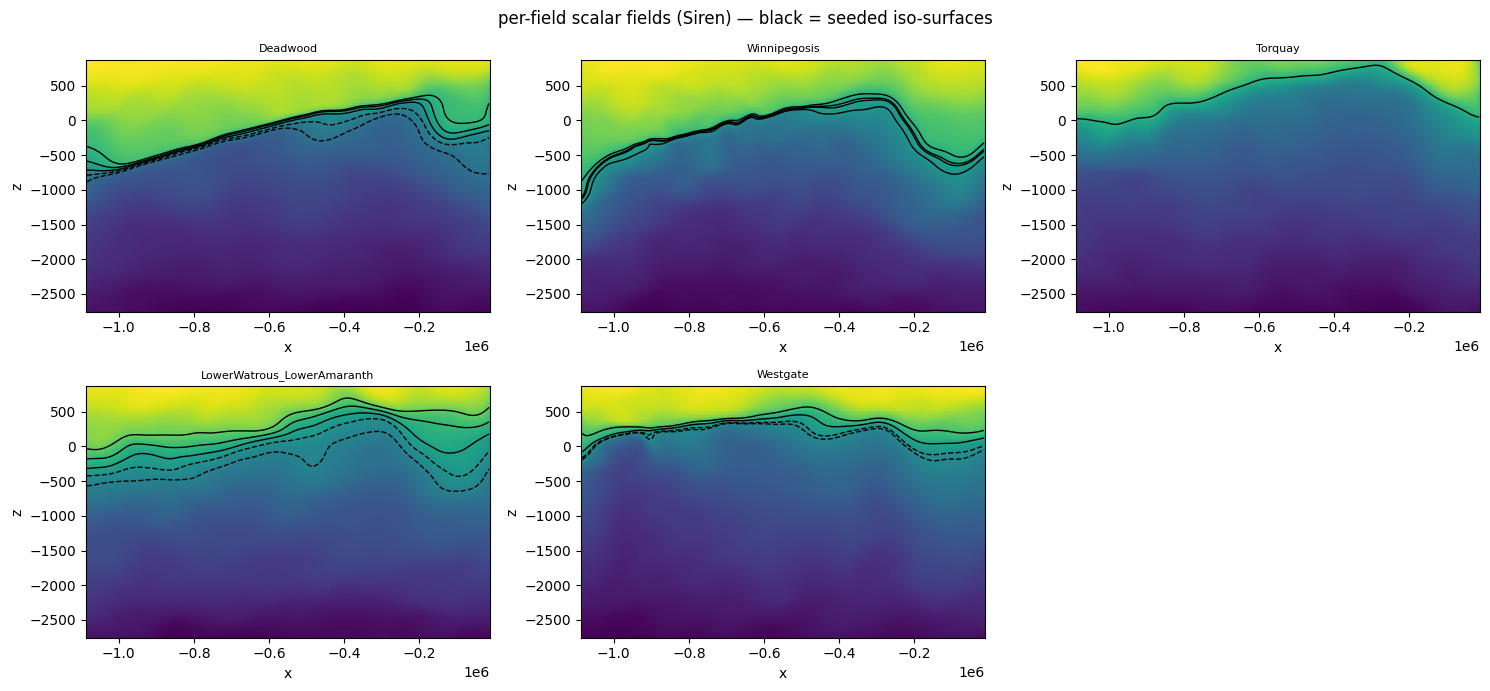

In [7]:
lo, hi = obs.bounds(); lo = np.asarray(lo, float); hi = np.asarray(hi, float)
center = 0.5 * (lo + hi)
nx, nz = 200, 130
xs = np.linspace(lo[0], hi[0], nx); zs = np.linspace(lo[2], hi[2], nz)
XX, ZZ = np.meshgrid(xs, zs); YY = np.full_like(XX, center[1])
SEC = np.stack([XX, YY, ZZ], axis=-1).reshape(-1, 3).astype(float)

# show a few events including the baselap-onto-conformal pairs
names = [m.name for m in M.field_meta if m.kind == "depositional"]
sel = [M[nm] for nm in names][::2][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for ax, ev in zip(axes, sel):
    g = ev.predict(T.apply(SEC), combine=False)   # this field only, model coords
    S = g.scalar.reshape(nz, nx)
    ax.pcolormesh(xs, zs, S, shading="auto", cmap="viridis")
    isov = sorted(ev.getIsovalues().values())
    if isov:
        ax.contour(xs, zs, S, levels=isov, colors="k", linewidths=1.0)
    ax.set_title(ev.name[:30], fontsize=8); ax.set_xlabel("x"); ax.set_ylabel("z")
for ax in axes[len(sel):]: ax.axis("off")
fig.suptitle(f"per-field scalar fields ({FIELD}) — black = seeded iso-surfaces")
plt.tight_layout(); plt.show()

## 5. Combined model — predict & 3D view (WebGL HTML viewer)

`M.predict` assembles all fields via the onlap/truncation combine — including the four
baselap-onto-conformal onlaps. The **WebGL HTML viewer** shows the lithology volume
(coloured by stratigraphic **level**), the observation points (coloured by their true
unit), and the extracted iso-surfaces. Look at the four baselap units: they should **lap
out** against the top of the conformal package below rather than draping conformably over
it. Outputs go to `outputs/` (git-ignored); set `OPEN_BROWSER=False` for headless runs.

grid cells: 8,089,200  shape (214, 210, 180)
scalar range -1.749352636791449 -> 2.152354337537704 | lithologies 45


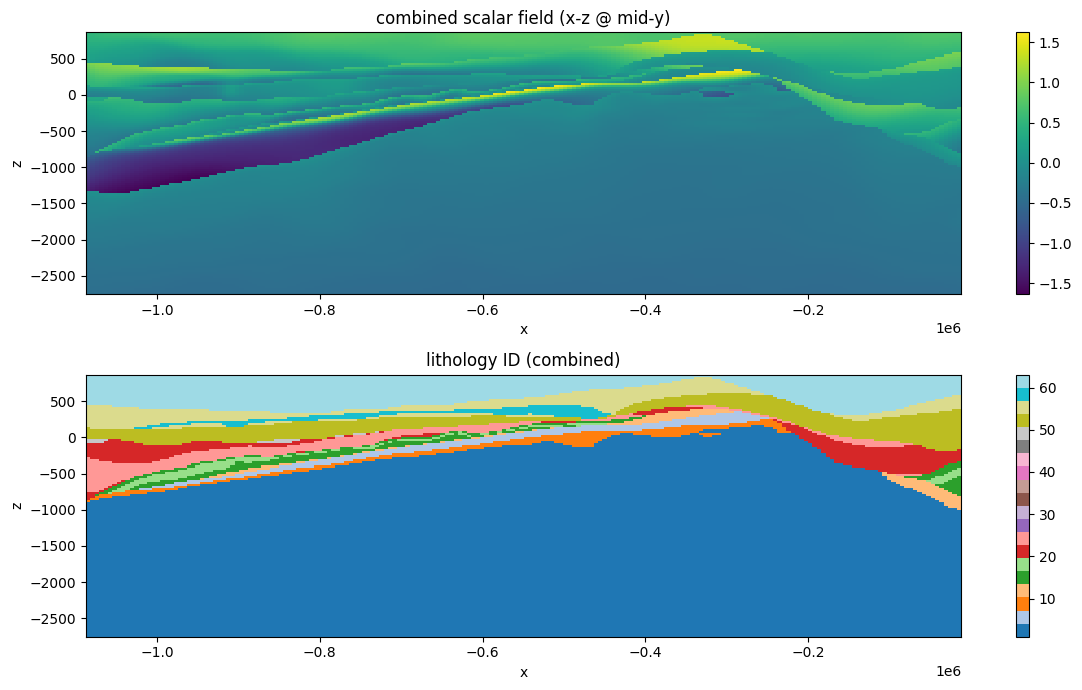

In [8]:
from curlew.geometry import Grid
RES_XY, RES_Z = 5000.0, 20.0
curlew.batchSize = 50000
ext = hi - lo
G = Grid(dims=tuple(ext), step=(RES_XY, RES_XY, RES_Z), center=tuple(center))
print(f"grid cells: {int(np.prod(G.shape)):,}  shape {G.shape}")
geode = M.predict(G)
print("scalar range", float(np.nanmin(geode.scalar)), "->", float(np.nanmax(geode.scalar)),
      "| lithologies", len(np.unique(geode.lithoID)))

sec = M.predict(SEC)
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
pcm = ax[0].pcolormesh(xs, zs, sec.scalar.reshape(nz, nx), shading="auto", cmap="viridis")
fig.colorbar(pcm, ax=ax[0]); ax[0].set_title("combined scalar field (x-z @ mid-y)")
pcm2 = ax[1].pcolormesh(xs, zs, sec.lithoID.reshape(nz, nx), shading="auto", cmap="tab20")
fig.colorbar(pcm2, ax=ax[1]); ax[1].set_title("lithology ID (combined)")
for a in ax: a.set_xlabel("x"); a.set_ylabel("z")
plt.tight_layout(); plt.show()

In [9]:
from pathlib import Path
from curlew.visualise.html_viewer import write_geomodel_viewer, serve_and_open

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
html = write_geomodel_viewer(
    OUT / "skmb_viewer.html", M, geode, G,
    obs=obs, color_by="level", mode="tiled", max_points=200000,
    title=f"skmb ({FIELD})", initial_z_exaggeration=100,
)
print("wrote", html)
serve_and_open(html)

Wrote outputs\skmb_viewer.html  (+ skmb_viewer_data/  283.39 MB)
wrote outputs\skmb_viewer.html
Serving D:\Development\curlew\examples\skmb\outputs
  -> http://127.0.0.1:63745/skmb_viewer.html
  (call .shutdown() on the returned server to stop it)


127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer.html HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/manifest.json HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] code 404, message File not found
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid/yvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid/xvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid/zvec.f32 HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid/categories.u8 HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid_mesh/tile_000.bin HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid_mesh/tile_001.bin HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:16:34] "GET /skmb_viewer_data/grid_mesh/tile_002.bin HTTP/1.1" 200 -
127.0.0.1 - - [25/Jun/2026 12:1

### Export for ParaView

Two files for closer inspection (written to `outputs/`, git-ignored):

- **Grid volume** (`curlew.io.saveVTK`) — `.vti` (`ImageData`, since this grid is
  axis-aligned; use `.vts` for a rotated grid). Each voxel carries `scalar`, `lithoID`
  (curlew's internal id) and **`level`** (the data's own stratigraphic convention:
  ascending = older, `-1` where not a unit — the array to colour by). The `lithoID→name`
  legend is embedded as field data (`lithoID_legend`).
- **Contact surfaces** (`.vtp`, `PolyData`) — every event's iso-surface(s) extracted with
  marching cubes (`Grid.contour`), **masked to where that event is the visible structure**
  (`structureID == eid`) so each contact appears only where it is an actual boundary — the
  same surfaces the HTML viewer shows. Each triangle carries the surface's `level` and a
  `surface_id`; the `surface_id→name` legend is embedded as field data. This includes the
  four baselap-onto-conformal contacts (the lower package's *top* iso) and the doubled
  unconformity surfaces.

Coordinates are **world** units (so z is the true thin extent — exaggerate z in ParaView,
e.g. Transform → Scale Z, to see the layering).

In [10]:
import pyvista as pv
from curlew.io import saveVTK

# --- grid volume (.vti) ---
lut = np.full(max(M.llookup.values()) + 1, -1, dtype=np.int32)
for L, key in M.level_litho.items():
    lut[M.llookup[key]] = L
saveVTK(OUT / "skmb_prediction.vti", geode, extra={"level": lut[geode.lithoID]})
print("wrote", OUT / "skmb_prediction.vti", f"({int(np.prod(G.shape)):,} cells)")

# --- contact surfaces (.vtp), masked to the visible structure (mirrors the HTML viewer) ---
sid = geode.structureID
name2litho = {n: i for i, n in geode.lithoLookup.items()}
lithoID2level = {M.llookup[key]: L for L, key in M.level_litho.items()}
parts, names = [], []
for e in M.events:
    if not getattr(e, "isosurfaces", None):
        continue
    mask = sid == e.eid
    if not mask.any():
        continue
    for iso_name, iso_val in e.getIsovalues().items():
        try:
            verts, faces = G.contour(geode.fields[e.name], iso=iso_val, mask=mask, erodeMask=-2)
        except Exception:   # iso outside the grid's value range etc.
            continue
        if len(verts) == 0 or len(faces) == 0:
            continue
        f = np.hstack([np.full((len(faces), 1), 3, np.int64), np.asarray(faces, np.int64)]).ravel()
        poly = pv.PolyData(np.asarray(verts, float), f)
        li = name2litho.get(f"{e.name}_{iso_name}")
        poly.cell_data["level"] = np.full(poly.n_cells, lithoID2level.get(li, -1), np.int32)
        poly.cell_data["surface_id"] = np.full(poly.n_cells, len(parts), np.int32)
        parts.append(poly); names.append(f"{e.name}_{iso_name}")

surfaces = parts[0].merge(parts[1:]) if len(parts) > 1 else parts[0]
surfaces.field_data["surface_legend"] = np.array([f"{i}: {n}" for i, n in enumerate(names)])
surfaces.save(OUT / "skmb_surfaces.vtp")
print(f"wrote {OUT / 'skmb_surfaces.vtp'}  ({len(parts)} surfaces, {surfaces.n_cells:,} triangles)")

wrote outputs\skmb_prediction.vti (8,089,200 cells)
wrote outputs\skmb_surfaces.vtp  (37 surfaces, 2,606,333 triangles)


## 6. Checks & diagnostics

**Asserted**: the event chain, that the four **baselap-onto-conformal** packages each onlap
a *depositional* package's seeded **top** isosurface (not an unconformity), and the
**soft-carve ↔ predict** consistency (the training assembly agrees with predict's hard
assembly, since both use the same seeded contacts + fields). Per-point band/structure
accuracy is reported.

In [11]:
results = {}
metas = M.field_meta
kinds = [m.kind for m in metas]
results["event_chain"] = bool(kinds[0] == "region-only"
                              and sum(m.is_unconformity for m in metas) >= 1
                              and sum(k == "depositional" for k in kinds) >= 1)
print(f"1. event chain: {len(metas)} events "
      f"({sum(k=='region-only' for k in kinds)} region, {sum(m.is_unconformity for m in metas)} erosional, "
      f"{sum(k=='depositional' for k in kinds)} depositional) -> {results['event_chain']}")

# 2. the four baselap-onto-conformal packages onlap a depositional top iso
onlaps = [m for m in metas if m.onlap_package]
ok = len(onlaps) == 4
for m in onlaps:
    lower = next(x for x in metas if x.name == m.onlap_event)
    ok &= bool(m.onlap_iso_id.endswith("::top") and lower.kind == "depositional"
               and lower.top_iso is not None and lower.top_iso in M[lower.name].isosurfaces)
results["baselap_onto_conformal"] = bool(ok)
print(f"2. baselap-onto-conformal onlaps: {len(onlaps)} packages onto depositional tops -> {results['baselap_onto_conformal']}")

# 3. soft-carve <-> predict consistency. Evaluate over modelled band levels (every observed
# unit is modelled here, including the Sub_Cantuar unit sandwiched between two unconformities,
# so this filter is a defensive no-op).
eval_levels = [L for L in obs.levels("unit") if L in M.level_litho]
rng = np.random.default_rng(7); cpts, clev = [], []
for L in eval_levels:
    idx = np.where((~obs.is_interface) & (obs.level == L))[0]
    idx = rng.choice(idx, size=min(300, len(idx)), replace=False)
    cpts.append(obs.coords[idx].astype(float)); clev.append(np.full(len(idx), L))
cpts = np.vstack(cpts); clev = np.concatenate(clev)
Xm = M.T(torch.tensor(cpts, dtype=curlew.dtype, device=curlew.device))
with torch.no_grad():
    cprobs = soft_unit_probs(M, Xm, uloss.resolve_isos(M), uloss.tau, uloss.spec)
carve_level = np.array([uloss.spec.class_levels[i] for i in cprobs.argmax(1).cpu().numpy()])
gp = M.predict(cpts)
lut2 = {M.llookup[key]: L for L, key in M.level_litho.items()}
pred_level = np.array([lut2.get(int(i), -1) for i in gp.lithoID])
soft_agree = float((carve_level == pred_level).mean())
results["soft_predict_consistent"] = bool(soft_agree >= 0.85)
print(f"3. soft-carve == predict (level space): {soft_agree:.4f} -> {results['soft_predict_consistent']}")

print("\n" + "=" * 48)
ASSERTED = ("event_chain", "baselap_onto_conformal", "soft_predict_consistent")
for k, v in results.items():
    print(f"  {('PASS' if v else 'FAIL'):6s} {k}")
assert all(results[k] for k in ASSERTED), "An asserted invariant failed."
print("=" * 48)

1. event chain: 19 events (2 region, 7 erosional, 10 depositional) -> True
2. baselap-onto-conformal onlaps: 4 packages onto depositional tops -> True
3. soft-carve == predict (level space): 0.9703 -> True

  PASS   event_chain
  PASS   baselap_onto_conformal
  PASS   soft_predict_consistent


In [12]:
# --- reported per-point accuracy (modelled band levels; see check 3) ---
rng = np.random.default_rng(3); pts, lev = [], []
for L in [L for L in obs.levels("unit") if L in M.level_litho]:
    idx = np.where((~obs.is_interface) & (obs.level == L))[0]
    idx = rng.choice(idx, size=min(400, len(idx)), replace=False)
    pts.append(obs.coords[idx].astype(float)); lev.append(np.full(len(idx), L))
pts = np.vstack(pts); lev = np.concatenate(lev); g = M.predict(pts)
litho = np.array([g.lithoLookup.get(int(i), "?") for i in g.lithoID])
struct = np.array([g.structureLookup.get(int(s), "?") for s in g.structureID])
lev_struct = {L: m.name for m in metas for L in m.levels}
lit_ok = np.array([litho[k] == M.level_litho[int(lev[k])] for k in range(len(lev))])
str_ok = np.array([struct[k] == lev_struct[int(lev[k])] for k in range(len(lev))])
print(f"band accuracy           : {lit_ok.mean():.3f}")
print(f"structure (package) acc : {str_ok.mean():.3f}")

band accuracy           : 0.822
structure (package) acc : 0.936
